In [2]:
# Text as Data Final Project
# Author: Sejal Jagtap

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import spacy

# load spacy model
nlp = spacy.load("en_core_web_sm")
stopwords = nlp.Defaults.stop_words

In [3]:
texts = {}
folder_path = "texts"

for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as f:
            texts[filename] = f.read()

print(f"Loaded {len(texts)} documents")

Loaded 23 documents


In [4]:
def split_sentences(text):
    return re.split(r"(?<=[.!?])\s+", text)


credit_windows = []
metadata = []

for doc_name, text in texts.items():
    sentences = split_sentences(text)

    for i, sent in enumerate(sentences):
        if re.search(r"\bcredit\w*\b", sent.lower()):

            start = max(0, i - 2)
            end = min(len(sentences), i + 3)

            window = " ".join(sentences[start:end])

            credit_windows.append(window)
            metadata.append(doc_name)

print(f"Extracted {len(credit_windows)} windows")

Extracted 389 windows


In [5]:
df_windows = pd.DataFrame({"document": metadata, "text": credit_windows})

df_windows.head()

,document,text
0,A32837.txt,at 6 per cent. in England; the like is in Toba...
1,A51598.txt,And because the nobleness of this Profession m...
2,A51598.txt,estates into Treasure; for they that have Ware...
3,A51598.txt,To grow rich and live without adventure at Sea...
4,A51598.txt,To take up Princes base money and to turn into...


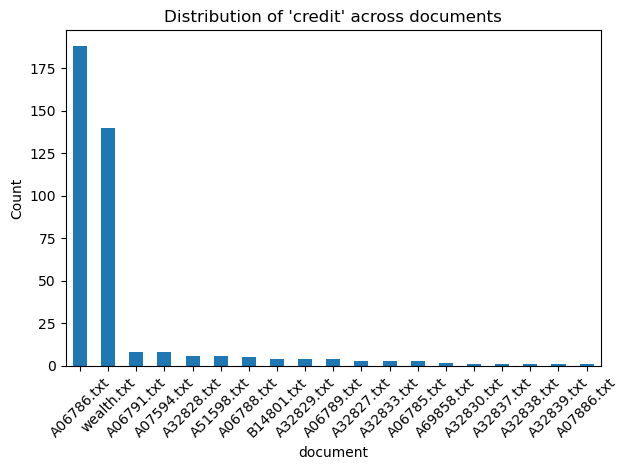

In [6]:
doc_counts = df_windows.groupby("document").size().sort_values(ascending=False)

plt.figure()
doc_counts.plot(kind="bar")
plt.title("Distribution of 'credit' across documents")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
words = []

for text in credit_windows:
    tokens = re.findall(r"\b\w+\b", text.lower())
    words.extend([w for w in tokens if w not in stopwords and len(w) > 2])

common_words = Counter(words).most_common(25)
common_words

[('money', 574),
 ('credit', 423),
 ('said', 395),
 ('debtor', 283),
 ('creditor', 268),
 ('great', 238),
 ('man', 237),
 ('exchange', 222),
 ('creditors', 214),
 ('merchant', 208),
 ('time', 202),
 ('shall', 191),
 ('bank', 189),
 ('merchants', 188),
 ('pay', 186),
 ('unto', 185),
 ('law', 182),
 ('trade', 175),
 ('account', 156),
 ('men', 153),
 ('goods', 150),
 ('hath', 146),
 ('interest', 144),
 ('commodities', 136),
 ('doth', 130)]

In [8]:
context_words = []

for text in credit_windows:
    tokens = re.findall(r"\b\w+\b", text.lower())

    for i, word in enumerate(tokens):
        if "credit" in word:
            window = tokens[max(0, i - 5) : i + 6]
            context_words.extend([w for w in window if w not in stopwords])

Counter(context_words).most_common(25)

[('credit', 451),
 ('creditor', 277),
 ('creditors', 234),
 ('debtor', 106),
 ('credits', 56),
 ('letters', 56),
 ('said', 55),
 ('public', 52),
 ('s', 52),
 ('bank', 43),
 ('money', 42),
 ('loss', 40),
 ('great', 33),
 ('ordinary', 33),
 ('profit', 29),
 ('state', 28),
 ('debt', 28),
 ('capital', 27),
 ('estate', 27),
 ('man', 26),
 ('sum', 25),
 ('good', 24),
 ('stock', 23),
 ('cash', 23),
 ('given', 22)]

### Step 2: NER

In [9]:
# NER Spacy

entities = []

for text in credit_windows:
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in ["ORG", "GPE"]:
            entities.append((ent.text.strip(), ent.label_))

df_entities = pd.DataFrame(entities, columns=["entity", "label"])

# Clean obvious false positives (common nouns misclassified as ORG)

invalid_entities = ["credit", "trade", "commission", "creditors", "creditor"]

df_entities_clean = df_entities[
    ~df_entities["entity"].str.lower().isin(invalid_entities)
]

In [10]:
freq_table = (
    df_entities_clean.groupby(["entity", "label"])
    .size()
    .reset_index(name="frequency")
    .sort_values(by="frequency", ascending=False)
)

freq_table.head(15)

,entity,label,frequency
173,England,GPE,62
180,Exchange,ORG,62
269,London,GPE,59
418,Spain,GPE,45
264,Letters of Credit,ORG,41
12,Amsterdam,GPE,38
38,Bank,ORG,37
40,Bankers,ORG,29
219,Holland,GPE,23
5,Account,ORG,21


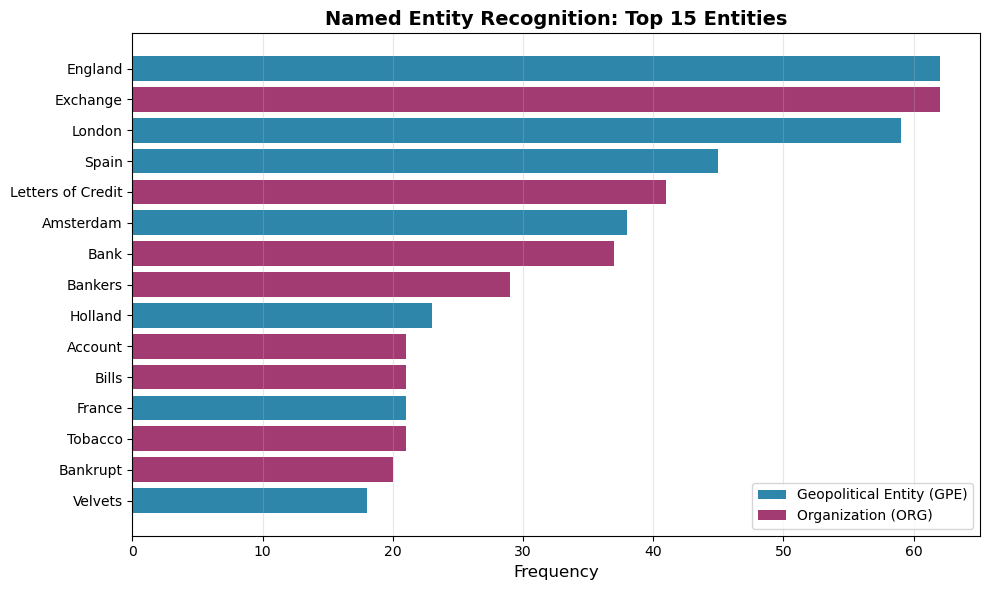

In [11]:
# Visualization of top 15 entities
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 15 entities
top_entities = freq_table.head(15).copy()

# Create the plot
plt.figure(figsize=(10, 6))
colors = {"GPE": "#2E86AB", "ORG": "#A23B72"}
bar_colors = [colors[label] for label in top_entities["label"]]

plt.barh(range(len(top_entities)), top_entities["frequency"], color=bar_colors)
plt.yticks(range(len(top_entities)), top_entities["entity"])
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("")
plt.title("Named Entity Recognition: Top 15 Entities", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()  # Highest frequency at top

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2E86AB", label="Geopolitical Entity (GPE)"),
    Patch(facecolor="#A23B72", label="Organization (ORG)")
]
plt.legend(handles=legend_elements, loc="lower right")

# Clean up grid
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
examples = []

for text in credit_windows:
    doc = nlp(text)
    ents = [ent.text for ent in doc.ents if ent.label_ in ["ORG", "GPE"]]

    if ents:
        examples.append((text, ents))

# print first 5 examples
for text, ents in examples[:5]:
    print("Entities:", ents)
    print(text[:300])
    print("\n---\n")

Entities: ['England', 'Tobacco', 'Virginia', 'Ireland', 'Land for Security']
at 6 per cent. in England; the like is in Tobacco in Virginia. In Ireland the like, at the rate of that Country; with this also that whoever can be credited for 1000 l. there must give 4000 l. worth of Land for Security; whereas 2000 l.

---

Entities: ['Profession', 'Debtor and Creditor', 'Bills of Lading', 'Contracts, Bills of Exchange', 'Policies os Insurance', 'Countries', 'Trade, & the', 'Kingdom']
And because the nobleness of this Profession may the better stir up thy desires and endeavours to obtain those abilities which may effect it worthily, I will briefly set down the excellent qualities which are required in a perfect Merchant. 1. He ought to be a good Penman, a good Arithmetician, and 

---

Entities: ['the Life of Trade', 'Nations', 'Foreign Trade', 'Kingdom', 'Realm', 'Nations']
estates into Treasure; for they that have Wares cannot want money. Neither is it said that Money is the Life of Trade,

In [54]:
freq_table.to_csv("entity_frequency.csv", index=False)

In [55]:
df_entities["entity"] = df_entities["entity"].str.lower()

Q1. Is the concept associated with people, institutions, or places?

The concept of “credit” is mostly connected to places and institutions, 
not specific people. We see many mentions of places like London, Amsterdam, 
and England, which were major trading centers at the time. This shows that 
credit is closely linked to trade happening across different locations.
We also see institutions like banks, exchanges, and “letters of credit,” 
which represent the systems and tools used for financial transactions.
Overall, this suggests that credit is not just about individuals, 
but about how trade and finance work across cities and organizations.

Q2. Do different entities correspond to different uses of the concept?

Yes, different types of entities are linked to different meanings of “credit.”
When credit appears with places (like London or Spain), it usually 
refers to trade between regions and how money and trust move across locations.
When it appears with institutions (like banks or exchanges), 
it refers more to formal financial systems, such as lending, 
accounting, and managing money.
So, the meaning of “credit” changes depending on the context -
sometimes it’s about trade networks, and sometimes about financial systems.

Q3. What are the limitations of NER in your corpus?

There are a few problems with using NER on this historical text.
First, the model sometimes gets confused and labels normal words as entities. 
For example, words like “account,” “bills,” or “tobacco” are tagged as 
organizations, even though they are just regular terms.
Second, the text is old, so spelling and capitalization are different from 
modern English. This makes it harder for the model to correctly identify entities.
Third, some important groups like merchants or traders are not detected at all, 
even though they are central to how credit works.
Finally, NER cannot capture the idea of reputation or trust, which is a big 
part of what “credit” means in these texts. It only picks up named things, 
not abstract ideas.

### Step 3: BERT

In [57]:
#!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [59]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [60]:
embeddings = model.encode(credit_windows)

In [61]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(embeddings)

df_windows["cluster"] = labels

In [62]:
# cluster distribution

df_windows["cluster"].value_counts()

cluster
2    157
0    125
1    107
Name: count, dtype: int64

In [63]:
for i in range(k):
    print(f"\nCluster {i}\n")

    cluster_texts = df_windows[df_windows["cluster"] == i]["text"].head(3)

    for text in cluster_texts:
        print("-", text[:200])
        print()


Cluster 0

- This course is agreeable to justice and the Ius gentium. Law of Nations, and will not hinder th' exchange to rise and fall as formerly; but keep all in due order, with those considerations, Cautions a

- 2. Although they have no Law expressly, limiting Interest at present, yet they have other Laws which we cannot yet arrive to, which do effect the same thing among them, and would do the like among us,

- 2. Although they have no Law expressly, limiting Interest at present, yet they have other Laws which we cannot yet arrive to, which do effect the same thing among them, and would do the like among us,


Cluster 1

- The ninth cause of the decay of Trade, consisting The ninth Cause. of the interruption thereof by Wars, Pirates, and Bankerupts, I have partly handled in the fifth Cause. And although decayed men are 

- And although decayed men are found at all times, yet the want of money hath caused diverse Merchants and Tradesmen to Break, who might have maintained then cr

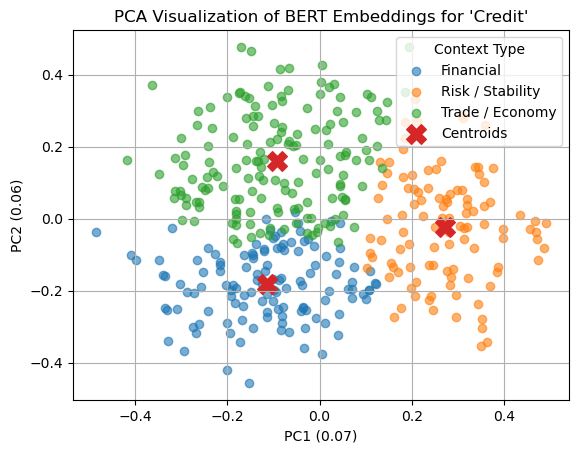

In [72]:
#  Reduce dimensions
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

#  Define cluster names (adjust if needed)
cluster_names = {0: "Financial", 1: "Risk / Stability", 2: "Trade / Economy"}

clusters = np.unique(labels)

#  Plot
plt.figure()

for cluster in clusters:
    idx = labels == cluster
    plt.scatter(
        reduced[idx, 0],
        reduced[idx, 1],
        alpha=0.6,
        label=cluster_names.get(cluster, f"Cluster {cluster}"),
    )

#  Plot cluster centroids
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=200, label="Centroids")

# Labels with explained variance
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2f})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2f})")

# Title + legend
plt.title("PCA Visualization of BERT Embeddings for 'Credit'")
plt.legend(title="Context Type")

plt.grid()

plt.show()

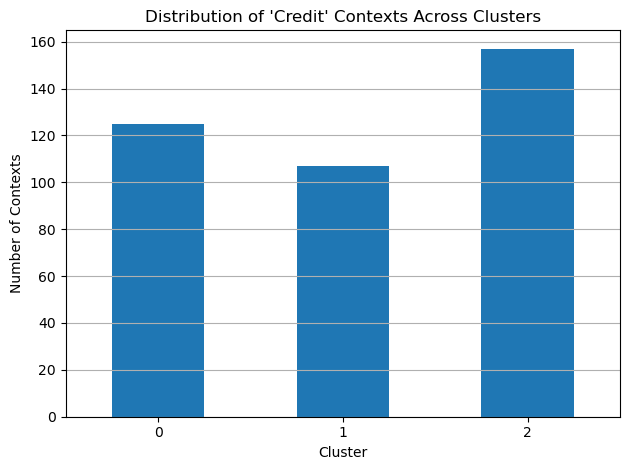

In [74]:
# cluster distribution

cluster_counts = pd.Series(labels).value_counts().sort_index()

plt.figure()
cluster_counts.plot(kind="bar")

plt.title("Distribution of 'Credit' Contexts Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Contexts")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

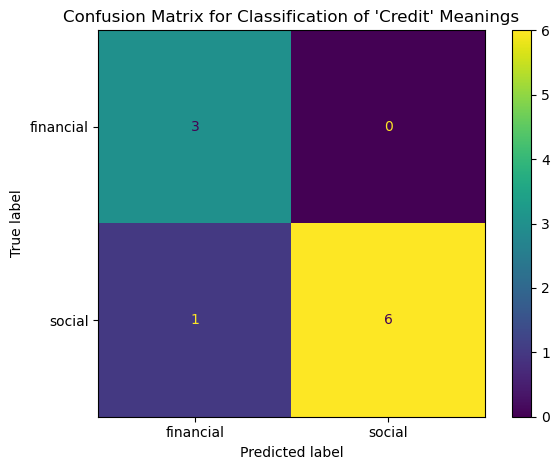

In [76]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

plt.figure()
disp.plot()

plt.title("Confusion Matrix for Classification of 'Credit' Meanings")
plt.grid(False)

plt.tight_layout()
plt.show()

The BERT embeddings of “credit” contexts were grouped using K-means clustering into three clusters. The visualization shows that the contexts form three relatively distinct groups, indicating that the model is capturing meaningful differences in how “credit” is used across the corpus.
While there is some overlap, the clusters are largely separable, suggesting that the concept appears in different semantic contexts rather than a single uniform meaning.

Q. Do you observe distinct meanings?
Yes, the clustering clearly shows that “credit” appears in distinct groups of contexts, meaning it does not have a single fixed meaning. The separation of clusters in the visualization suggests that the model is able to capture different ways the word is used based on its surrounding text.

Q. What are the meanings?

Cluster 1 — Financial / Accounting
One cluster represents the financial meaning of credit, where it is used in technical contexts involving debt, accounting, and transactions. These examples include references to debtor-creditor relationships, accounts, and financial records.

Cluster 2 — Trade / Network
Another cluster reflects credit as part of trade networks, where it appears alongside references to places such as London or Amsterdam. In these contexts, credit is about enabling exchange across regions and supporting commercial activity.

Cluster 3 — Reputation / Trust
A third cluster captures the social meaning of credit, where it refers to trust, reputation, or reliability. In these cases, credit is about how trustworthy a person or group is, rather than just financial transactions.

The differences between clusters show that “credit” is a flexible concept that changes depending on context. In some cases, it refers to formal financial systems, while in others it describes trade relationships or social trust. These meanings are related but emphasize different aspects of how credit functions in early modern society.
Overall, the clustering confirms that the meaning of “credit” is context-dependent, supporting the idea that words do not have a single fixed meaning but vary based on usage.

### Step 4: Logistic Regression

In [65]:
def assign_label(cluster):
    if cluster == 0:
        return "financial"
    elif cluster == 2:
        return "social"
    else:
        return None  # ignore trade for now


df_windows["label"] = df_windows["cluster"].apply(assign_label)

# keep only labeled data
df_labeled = df_windows.dropna(subset=["label"])

df_labeled["label"].value_counts()

label
social       157
financial    125
Name: count, dtype: int64

In [66]:
df_sample = df_labeled.groupby("label").sample(n=25, random_state=42)

df_sample["label"].value_counts()

label
financial    25
social       25
Name: count, dtype: int64

In [67]:
X = model.encode(df_sample["text"].tolist())
y = df_sample["label"]

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
# Evaluate performance
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   financial       0.75      1.00      0.86         3
      social       1.00      0.86      0.92         7

    accuracy                           0.90        10
   macro avg       0.88      0.93      0.89        10
weighted avg       0.93      0.90      0.90        10



In [70]:
X_all = model.encode(df_labeled["text"].tolist())

df_labeled["predicted"] = clf.predict(X_all)

df_labeled.head()

/var/folders/bm/2r9q_8x14n58_y3c1q4rc9cr0000gn/T/ipykernel_69351/314014360.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labeled["predicted"] = clf.predict(X_all)


,document,text,cluster,label,predicted
0,A32837.txt,at 6 per cent. in England; the like is in Toba...,2,social,social
1,A51598.txt,And because the nobleness of this Profession m...,2,social,social
2,A51598.txt,estates into Treasure; for they that have Ware...,2,social,financial
3,A51598.txt,To grow rich and live without adventure at Sea...,2,social,social
4,A51598.txt,To take up Princes base money and to turn into...,2,social,social


Q1. How well does the model distinguish meanings?

The model performs quite well overall, with an accuracy of 90%. It correctly identifies most examples of both financial and social meanings of “credit.” In particular, it achieves perfect recall (1.00) for financial cases, meaning it successfully identifies all financial examples in the test set.
The performance for social meanings is also strong, with high precision and recall, showing that the model can reliably distinguish between the two types of usage.
However, the test set is small (only 10 examples), so while the results are promising, they should be interpreted with some caution.

Q2. What features seem to drive classification?

The model relies on patterns in the surrounding text captured by the BERT embeddings. Contexts that include financial terms—such as money, accounts, exchange, or transactions—tend to be classified as financial.
On the other hand, contexts that include words related to trust, reputation, or personal standing are more likely to be classified as social.
This shows that the model is not just looking at the word “credit” itself, but is using the context around it to understand its meaning.

Q3. Where does the model fail?

The model tends to make mistakes in cases where the meaning of “credit” is unclear or overlaps between categories. For example, one instance that was labeled as social was predicted as financial. This likely happened because the context included both reputation-related and financial elements, making it difficult to classify cleanly.
This reflects a key challenge in the concept itself: in early modern texts, financial credit and social trust are often closely connected, rather than completely separate.
Additionally, the small training dataset limits the model’s ability to generalize, and some errors may also come from imperfect labeling based on clustering. These issues highlight that while the model works well, it does not fully capture the complexity of the concept.

Overall, the results suggest that while the meanings of “credit” are distinguishable, they are also partially overlapping, reflecting the concept’s inherently hybrid nature.

Step 5: Synthesis - Refer report

Central Claim: 

The concept of “credit” in this corpus is not a single fixed idea, but a multi-dimensional concept structured across three interconnected meanings: financial, networked (trade), and reputational. These meanings are not separate, but overlap and reinforce each other, reflecting how early modern economic life combined systems of finance, geographic trade networks, and social trust.